# 06 — What the analyst sees: a BOUNDED query result

An analyst asks a simple question: **"Show me revenue by day, as of June 9."**

What they don't know: the data retention policy deleted the first four days
of order history last week. This notebook shows what lands on their screen —
and, importantly, that the result is **plain, typed SQL** a BI tool can
consume, not a Python trick.

The contract (straight from the spec — *annotation, not value masking*):

| Column | Type | Meaning |
|---|---|---|
| measures (`orders`, `revenue`) | `INT` / `DOUBLE` | real values; `NULL` when unknowable |
| `epistemic` | `VARCHAR` | `OBSERVED` = verified · `BEYOND` = deleted by retention · `ABSENT` = no data ever existed (a real zero) |

`NULL + OBSERVED` is a genuine null. `NULL + BEYOND` is destroyed evidence.
The pair of columns carries three-valued semantics through a two-valued type
system — and the `epistemic` column is an ordinary dimension: filter on it,
group by it, drive conditional formatting from it.

*(Run with the repo `.venv` kernel — `pip install -e ".[all]"`.)*

In [1]:
# --- The situation: 10 days of orders (none on June 7), then retention runs ---
import shutil, time, json
from pathlib import Path
from datetime import datetime, timezone, date, timedelta
import pandas as pd
from deltalake import DeltaTable, write_deltalake
import alethe

WS = Path("bounded_workspace")
if WS.exists():
    shutil.rmtree(WS)
WS.mkdir()
ORDERS = WS / "orders"
DATES = [date(2026, 6, 1) + timedelta(days=d) for d in range(10)]

for d in range(10):
    if d == 6:
        continue                      # June 7: store closed — genuinely no orders
    write_deltalake(ORDERS, pd.DataFrame({
        "order_date": [DATES[d]] * 3,
        "order_id":   [f"D{d}-{i}" for i in range(3)],
        "amount":     [round(100.0 * (d + 1) + i * 10, 2) for i in range(3)],
    }), mode="append")
    time.sleep(1.0)

DeltaTable(str(ORDERS)).delete("order_date < '2026-06-05'")   # retention: purge June 1-4
removed = DeltaTable(str(ORDERS)).vacuum(
    retention_hours=0, enforce_retention_duration=False, dry_run=False)

wm = alethe.watermark(ORDERS)
BOUNDARY_DATE = date(2026, 6, 5)      # the retention horizon, in the key domain
print(f"Orders written June 1-10 (June 7: none). Retention deleted June 1-4, "
      f"VACUUM destroyed {len(removed)} files.")
print(f"alethe watermark: boundary v{wm.boundary['version']}, "
      f"empirically validated: {wm.empirically_validated}")

Orders written June 1-10 (June 7: none). Retention deleted June 1-4, VACUUM destroyed 4 files.
alethe watermark: boundary v9, empirically validated: True


## Without alethe: the query just breaks

The engine's own log says June 9 is available. It is not.

In [2]:
def commit_time(version: int) -> datetime:
    log = ORDERS / "_delta_log" / f"{version:020d}.json"
    for line in log.read_text().splitlines():
        a = json.loads(line)
        if "commitInfo" in a:
            return datetime.fromtimestamp(a["commitInfo"]["timestamp"] / 1000,
                                          tz=timezone.utc)

as_of = commit_time(7)   # the June 9 append (one write was skipped)
try:
    dt = DeltaTable(str(ORDERS))
    dt.load_as_version(as_of)
    dt.to_pyarrow_table()
except FileNotFoundError:
    print("SELECT * FROM orders TIMESTAMP AS OF '2026-06-09'")
    print("\n❌ FileNotFoundError: part-00001-...snappy.parquet not found")
    print("\nThat's the whole user experience. A stack trace — or on some")
    print("engines, a smaller result with no hint that anything is missing.")

SELECT * FROM orders TIMESTAMP AS OF '2026-06-09'

❌ FileNotFoundError: part-00001-...snappy.parquet not found

That's the whole user experience. A stack trace — or on some
engines, a smaller result with no hint that anything is missing.


## With alethe: the same query, one call

`alethe.asof()` takes the analyst's SQL **verbatim** — time-travel syntax
and all — gates every referenced table against its watermark, and returns
a typed DataFrame with the honest banner attached. UNACHIEVABLE raises;
CERTAIN time-travels for real; BOUNDED serves the surviving evidence and
says exactly what that means for *this table's* write pattern.

In [3]:
# The exact same query that crashed above — one call, honest result
res = alethe.asof(
    f"""SELECT order_date, SUM(amount) AS revenue
       FROM orders TIMESTAMP AS OF '{as_of.strftime('%Y-%m-%d %H:%M:%S')}'
       GROUP BY order_date ORDER BY order_date""",
    tables={"orders": str(ORDERS)},
)
res      # in a notebook, this renders the banner + the typed table

order_date,revenue
2026-06-05,1530.0
2026-06-06,1830.0
2026-06-08,2430.0
2026-06-09,2730.0
2026-06-10,3030.0


In [4]:
print("status :", res.status)
print("dtypes :", dict(res.df.dtypes.astype(str)))
# and the refusal case — before the table existed:
from alethe.integrations import UnachievableQueryError
try:
    alethe.asof("SELECT * FROM orders TIMESTAMP AS OF '2020-01-01'",
                tables={"orders": str(ORDERS)})
except UnachievableQueryError as e:
    print("\nREFUSED:", str(e)[:110])

status : BOUNDED
dtypes : {'order_date': 'datetime64[us]', 'revenue': 'float64'}

REFUSED: AS OF 2020-01-01T00:00:00+00:00 precedes the existence of delta://orders. No honest answer exists — the popula


## With alethe: one SQL view, consumable by any BI tool

`epistemic_view_sql` renders the contract as a single plain-SQL SELECT: the
date spine (the known population) LEFT JOINed to the surviving facts, with
the boundary deciding BEYOND vs ABSENT for the gaps. No Python in the
result path — register it as a view and point Tableau/Power BI/Looker at it.

In [5]:
import duckdb
from alethe.integrations import epistemic_view_sql, lower_bound_sql

con = duckdb.connect()
con.register("orders_surviving",
             DeltaTable(str(ORDERS)).to_pyarrow_table())   # the readable evidence
con.execute("""
    create table dim_date as
    select unnest(generate_series(DATE '2026-06-01', DATE '2026-06-09',
                                  INTERVAL 1 DAY))::DATE as order_date
""")

view = epistemic_view_sql(
    observed=("SELECT order_date, COUNT(*) AS orders, SUM(amount) AS revenue "
              "FROM orders_surviving GROUP BY order_date"),
    spine="SELECT order_date FROM dim_date",
    key="order_date",
    boundary=f"DATE '{BOUNDARY_DATE}'",
    measures=["orders", "revenue"],
)
print(view)

SELECT s.order_date,
       o.orders,
       o.revenue,
       CASE
         WHEN o.order_date IS NOT NULL THEN 'OBSERVED'
         WHEN s.order_date < DATE '2026-06-05' THEN 'BEYOND'
         ELSE 'ABSENT'
       END AS epistemic
FROM (SELECT order_date FROM dim_date) s
LEFT JOIN (SELECT order_date, COUNT(*) AS orders, SUM(amount) AS revenue FROM orders_surviving GROUP BY order_date) o ON s.order_date = o.order_date


In [6]:
result = con.execute(view + " ORDER BY order_date").fetch_df()
print(result.to_string(index=False))
print()
print("column types (intact — measures stay numeric, NULL where unknowable):")
print(result.dtypes.to_string())

order_date  orders  revenue epistemic
2026-06-01    <NA>      NaN    BEYOND
2026-06-02    <NA>      NaN    BEYOND
2026-06-03    <NA>      NaN    BEYOND
2026-06-04    <NA>      NaN    BEYOND
2026-06-05       3   1530.0  OBSERVED
2026-06-06       3   1830.0  OBSERVED
2026-06-07    <NA>      NaN    ABSENT
2026-06-08       3   2430.0  OBSERVED
2026-06-09       3   2730.0  OBSERVED

column types (intact — measures stay numeric, NULL where unknowable):
order_date    datetime64[us]
orders                 Int64
revenue              float64
epistemic                str


Note the three different kinds of "no number":

- **June 1–4 → `BEYOND`**: orders existed; their evidence was deleted by retention
- **June 7 → `ABSENT`**: inside retention, verified — there genuinely were no orders (a real zero)
- **June 5, 6, 8, 9 → `OBSERVED`**: verified values

A naive result would render June 1–4 and June 7 identically (missing), and
the analyst would read five days of "no sales." One of those five is true.

### How a BI tool renders it

The `epistemic` column drives conditional formatting — this is the same
typed frame, styled at display time only:

In [7]:
from IPython.display import Markdown, display

LABEL = {"OBSERVED": "✓ verified", "BEYOND": "deleted by retention",
         "ABSENT": "no orders (verified)"}
shown = result.assign(
    Date=[d.strftime("%b %d") for d in result.order_date],
    Status=[LABEL[e] for e in result.epistemic],
)[["Date", "orders", "revenue", "Status"]]

def style_rows(row):
    css = {"✓ verified":            "background-color:#f0f9f0",
           "deleted by retention":  "background-color:#f2f2f2; color:#a0a0a0; font-style:italic",
           "no orders (verified)":  "background-color:#fbfbe8"}[row.Status]
    return [css] * 4

display(shown.style
        .apply(style_rows, axis=1)
        .format({"revenue": lambda v: "—" if pd.isna(v) else f"${v:,.0f}",
                 "orders":  lambda v: "—" if pd.isna(v) else f"{int(v)}"})
        .hide(axis="index")
        .set_caption("Revenue by day — as of June 9, 2026")
        .set_table_styles([
            {"selector": "caption", "props": "font-size:1.1em; font-weight:bold; padding:8px;"},
            {"selector": "th", "props": "text-align:left; padding:6px 14px; border-bottom:2px solid #ccc;"},
            {"selector": "td", "props": "text-align:left; padding:6px 14px;"},
        ]))

Date,orders,revenue,Status
Jun 01,—,—,deleted by retention
Jun 02,—,—,deleted by retention
Jun 03,—,—,deleted by retention
Jun 04,—,—,deleted by retention
Jun 05,3,"$1,530",✓ verified
Jun 06,3,"$1,830",✓ verified
Jun 07,—,—,no orders (verified)
Jun 08,3,"$2,430",✓ verified
Jun 09,3,"$2,730",✓ verified


### The headline number — also SQL

`lower_bound_sql` aggregates the view into a floor plus an
`is_lower_bound` flag. In a dashboard, the flag drives the "≥" prefix and
the footnote — the measure itself stays a plain `DOUBLE`.

In [8]:
agg_sql = lower_bound_sql(view=view, measure="revenue")
print(agg_sql, "\n")
agg = con.execute(agg_sql).fetch_df()
print(agg.to_string(index=False))

floor = agg.revenue_floor.iloc[0]
n_gone = int(agg.keys_unknowable.iloc[0])
display(Markdown(f"""
### Total revenue, June 1–9: **at least ${floor:,.0f}**

> ⚠️ **{n_gone} of 9 days (June 1–4) were deleted by the data retention
> policy** and are not included. Because orders only accumulate, the true
> total is **higher than ${floor:,.0f} — never lower.** (June 7 shows no
> revenue because there genuinely were no orders — that's a verified zero,
> not a gap.)
"""))

SELECT SUM(revenue)                                        AS revenue_floor,
       BOOL_OR(epistemic = 'BEYOND')                AS is_lower_bound,
       COUNT(*) FILTER (WHERE epistemic = 'BEYOND') AS keys_unknowable
FROM (SELECT s.order_date,
       o.orders,
       o.revenue,
       CASE
         WHEN o.order_date IS NOT NULL THEN 'OBSERVED'
         WHEN s.order_date < DATE '2026-06-05' THEN 'BEYOND'
         ELSE 'ABSENT'
       END AS epistemic
FROM (SELECT order_date FROM dim_date) s
LEFT JOIN (SELECT order_date, COUNT(*) AS orders, SUM(amount) AS revenue FROM orders_surviving GROUP BY order_date) o ON s.order_date = o.order_date) 

 revenue_floor  is_lower_bound  keys_unknowable
        8520.0            True                4



### Total revenue, June 1–9: **at least $8,520**

> ⚠️ **4 of 9 days (June 1–4) were deleted by the data retention
> policy** and are not included. Because orders only accumulate, the true
> total is **higher than $8,520 — never lower.** (June 7 shows no
> revenue because there genuinely were no orders — that's a verified zero,
> not a gap.)


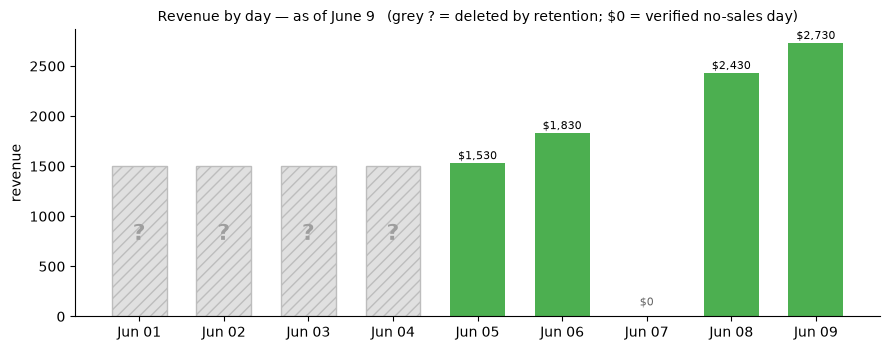

In [9]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(9, 3.6))
known_max = result.revenue.max()
for i, row in result.iterrows():
    label = row.order_date.strftime("%b %d")
    if row.epistemic == "OBSERVED":
        ax.bar(label, row.revenue, color="#4caf50", width=0.65)
        ax.text(i, row.revenue + 40, f"${row.revenue:,.0f}", ha="center", fontsize=8)
    elif row.epistemic == "BEYOND":
        ax.bar(label, known_max * 0.55, color="#e0e0e0", width=0.65,
               hatch="///", edgecolor="#bdbdbd")
        ax.text(i, known_max * 0.28, "?", ha="center", fontsize=16,
                color="#9e9e9e", fontweight="bold")
    else:  # ABSENT — a verified zero
        ax.bar(label, 0, color="#4caf50", width=0.65)
        ax.text(i, known_max * 0.04, "$0", ha="center", fontsize=8, color="#666")
ax.set_title("Revenue by day — as of June 9   "
             "(grey ? = deleted by retention; $0 = verified no-sales day)",
             fontsize=10)
ax.set_ylabel("revenue")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The grey bars are **questions**; the flat June 7 bar is a **verified
zero**. Without the epistemic column those two render identically — and
one of them is a lie.

---

## One caveat that matters: "at least" only works for some tables

The floor was safe because orders **accumulate** — deleting old ones can
only remove revenue from view. Tables that get **replaced** each load
(account balances, inventory levels) don't work that way. There, the
honest report shows the closest surviving day and says so:

In [10]:
OVR = WS / "balances"
for v, bal in enumerate([500.0, 800.0, 300.0, 650.0]):   # moves up AND down
    write_deltalake(OVR, pd.DataFrame({"account": ["A-1042"], "balance": [bal],
                                       "day": [v]}), mode="overwrite")
    time.sleep(1.0)
DeltaTable(str(OVR)).vacuum(retention_hours=0,
                            enforce_retention_duration=False, dry_run=False)
wm_b = alethe.watermark(OVR)
bv = wm_b.boundary["version"]
shown_b = DeltaTable(str(OVR), version=bv).to_pyarrow_table().to_pandas()

card = pd.DataFrame([{
    "Account": "A-1042",
    "You asked for": "balance on June 2",
    "Showing": f"${shown_b.balance.iloc[0]:,.0f}",
    "From": f"June {int(shown_b.day.iloc[0]) + 1} (closest surviving day)",
    "Note": "June 2 was deleted by retention. Its true balance is "
            "unrecoverable and may have been higher or lower.",
}])
(card.style.hide(axis="index")
 .set_caption("Account balance — closest available answer")
 .set_table_styles([
     {"selector": "caption", "props": "font-size:1.05em; font-weight:bold; padding:8px;"},
     {"selector": "th", "props": "text-align:left; padding:6px 12px; border-bottom:2px solid #ccc;"},
     {"selector": "td", "props": "text-align:left; padding:6px 12px; max-width:340px;"},
 ]))

Account,You asked for,Showing,From,Note
A-1042,balance on June 2,$650,June 4 (closest surviving day),June 2 was deleted by retention. Its true balance is unrecoverable and may have been higher or lower.


*(For the record: the deleted June 2 balance was $800 — the shown $650 is
neither a floor nor a ceiling. That's why this presentation says "closest
surviving day" instead of "at least.")*

---

## Under the hood (for the geeks)

The view's CASE expression is the observability semiring flattened into
SQL: `OBSERVED`/`BEYOND`/`ABSENT` are the three carrier values, the spine
is the known population, and the boundary comes from the empirically
validated watermark. The verdict machinery that decides *when* to route a
query through this view:

In [11]:
v = alethe.verdict(wm, since=as_of)
print("verdict :", v)
report = alethe.pit_report("orders", [wm])
zone = report.query(as_of)
print("zone    :", zone.status.value, "— limiting:", zone.limiting_chains)
print("\nEXACT/CERTAIN queries go straight to the engine; BOUNDED queries")
print("get served through the epistemic view; UNACHIEVABLE queries refuse.")

verdict : Verdict(BOUNDED, limiting=['delta://orders'])
zone    : BOUNDED — limiting: ['delta://orders']

EXACT/CERTAIN queries go straight to the engine; BOUNDED queries
get served through the epistemic view; UNACHIEVABLE queries refuse.
